In [1]:
# Preprocesamiento de datos

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# Entrenamiento de modelo

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

# Metricas

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix


In [ ]:
monday_ds = pd.read_csv('/Users/esemb/Desktop/code/cei/proyecto_final_morgado_blanar/dataset/Monday-WorkingHours.pcap_ISCX.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'proyecto_final_morgado_blanar/dataset/Monday-WorkingHours.pcap_ISCX.csv'

In [ ]:
wednesday_ds = pd.read_csv('/Users/esemb/Desktop/code/cei/proyecto_final_morgado_blanar/dataset/Wednesday-workingHours.pcap_ISCX.csv')

In [ ]:
monday_ds.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
wednesday_ds.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
monday_ds.info

<bound method DataFrame.info of          Destination Port   Flow Duration   Total Fwd Packets  \
0                   49188               4                   2   
1                   49188               1                   2   
2                   49188               1                   2   
3                   49188               1                   2   
4                   49486               3                   2   
...                   ...             ...                 ...   
529913                443           18738                   1   
529914                 53           60797                   2   
529915                 53             154                   2   
529916                 53             155                   2   
529917              52400              18                   1   

         Total Backward Packets  Total Length of Fwd Packets  \
0                             0                           12   
1                             0                           1

In [ ]:
wednesday_ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             692703 non-null  int64  
 1    Flow Duration                692703 non-null  int64  
 2    Total Fwd Packets            692703 non-null  int64  
 3    Total Backward Packets       692703 non-null  int64  
 4   Total Length of Fwd Packets   692703 non-null  int64  
 5    Total Length of Bwd Packets  692703 non-null  int64  
 6    Fwd Packet Length Max        692703 non-null  int64  
 7    Fwd Packet Length Min        692703 non-null  int64  
 8    Fwd Packet Length Mean       692703 non-null  float64
 9    Fwd Packet Length Std        692703 non-null  float64
 10  Bwd Packet Length Max         692703 non-null  int64  
 11   Bwd Packet Length Min        692703 non-null  int64  
 12   Bwd Packet Length Mean       692703 non-null  float64


In [ ]:
monday_ds[' Label'].value_counts()

 Label
BENIGN    529918
Name: count, dtype: int64

In [ ]:
wednesday_ds[' Label'].value_counts()

 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

In [ ]:
monday_ds.columns = monday_ds.columns.str.strip()

In [ ]:
wednesday_ds.columns = wednesday_ds.columns.str.strip()

In [ ]:
wednesday_ds['Label'].value_counts()

Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

In [ ]:
with pd.option_context('display.max_rows', None):
    display(monday_ds.isna().sum())

Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Max           0
Fwd Packet Length Min           0
Fwd Packet Length Mean          0
Fwd Packet Length Std           0
Bwd Packet Length Max           0
Bwd Packet Length Min           0
Bwd Packet Length Mean          0
Bwd Packet Length Std           0
Flow Bytes/s                   64
Flow Packets/s                  0
Flow IAT Mean                   0
Flow IAT Std                    0
Flow IAT Max                    0
Flow IAT Min                    0
Fwd IAT Total                   0
Fwd IAT Mean                    0
Fwd IAT Std                     0
Fwd IAT Max                     0
Fwd IAT Min                     0
Bwd IAT Total                   0
Bwd IAT Mean                    0
Bwd IAT Std                     0
Bwd IAT Max                     0
Bwd IAT Min   

In [ ]:
with pd.option_context('display.max_rows', None):
    display(wednesday_ds.isna().sum())

Destination Port                  0
Flow Duration                     0
Total Fwd Packets                 0
Total Backward Packets            0
Total Length of Fwd Packets       0
Total Length of Bwd Packets       0
Fwd Packet Length Max             0
Fwd Packet Length Min             0
Fwd Packet Length Mean            0
Fwd Packet Length Std             0
Bwd Packet Length Max             0
Bwd Packet Length Min             0
Bwd Packet Length Mean            0
Bwd Packet Length Std             0
Flow Bytes/s                   1008
Flow Packets/s                    0
Flow IAT Mean                     0
Flow IAT Std                      0
Flow IAT Max                      0
Flow IAT Min                      0
Fwd IAT Total                     0
Fwd IAT Mean                      0
Fwd IAT Std                       0
Fwd IAT Max                       0
Fwd IAT Min                       0
Bwd IAT Total                     0
Bwd IAT Mean                      0
Bwd IAT Std                 

### Filas vacias

#### `monday_ds`
- Flow Bytes/s : 64

#### `wednesday_ds`
- Flow Bytes/s : 1008

In [ ]:
# Limpieza de NaN e infinitos en Flow Bytes/s y Flow Packets/s.
# Problema documentado del extractor CICFlowMeter: división por Flow Duration=0
# produce ±inf, que despues pandas interpreta como NaN o como inf literal según la versión. 
# Referencia: Engelen et al. (2021), "Troubleshooting an Intrusion Detection Dataset".

for df_name, df in [('monday_ds', monday_ds), ('wednesday_ds', wednesday_ds)]:
    before = len(df)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"{df_name}: {before} → {len(df)} filas (descartadas {before - len(df)})")

monday_ds: 529918 → 529481 filas (descartadas 437)
wednesday_ds: 692703 → 691406 filas (descartadas 1297)


In [ ]:
with pd.option_context('display.max_columns', None):
    display(monday_ds[monday_ds['Flow Bytes/s'].isna()])

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label


In [ ]:
with pd.option_context('display.max_columns', None):
    display(wednesday_ds[wednesday_ds['Flow Bytes/s'].isna()])

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label


### Preprocesamiento
- Reducción del dataset con especial atención al orden (requerimiento LSTM)

In [ ]:
monday_v1 = monday_ds.iloc[100_000:150_000].reset_index(drop=True)

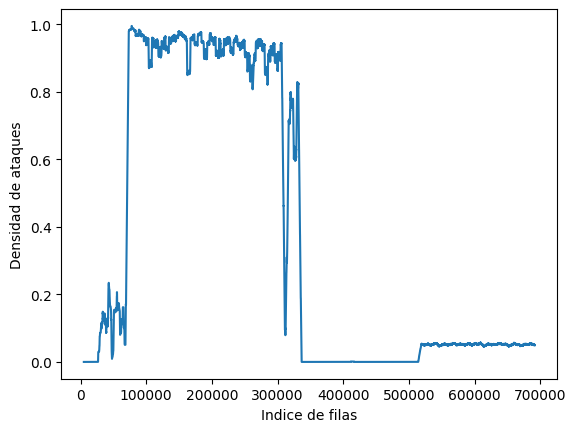

BENIGN
filas: 0 – 691405,  total: 439683

DoS slowloris
filas: 6548 – 69210,  total: 5796

DoS Slowhttptest
filas: 69212 – 74796,  total: 5499

DoS Hulk
filas: 74797 – 330001,  total: 230124

DoS GoldenEye
filas: 330002 – 691399,  total: 10293

Heartbleed
filas: 595894 – 596589,  total: 11



In [ ]:
# Analisis exploratorio: densidad local de ataques

wed = wednesday_ds.copy()
wed['Label'] = wed['Label'].str.strip()
wed['is_attack'] = (wed['Label'] != 'BENIGN').astype(int)

wed['is_attack'].rolling(5000).mean().plot()
plt.xlabel('Indice de filas'); plt.ylabel('Densidad de ataques'); plt.show()

# Reviso que tipo de ataque se encuentra en que rango
for label in wed['Label'].unique():
    idx = wed.index[wed['Label'] == label]
    print(f"{label}\nfilas: {idx.min()} – {idx.max()},  total: {len(idx)}\n")

In [ ]:
# Al reducir el dataset a 50.000 filas, obtengo el rango de filas
# que mayor represente a las amenazas. 
# Escogo el rango 40.000 -> 90.000 ya que me permite
# obtener una ampla gama de BENIGNOS y de ataques "DoS slowloris", "DoS Slowhttptest" y "DoS Hulk" 
# Dejo de lado "DoS GoldenEye" y "Heartbleed" -> Fuera del rango

wednesday_v1 = wednesday_ds.iloc[40_000:90_000].reset_index(drop=True) 

In [ ]:
wednesday_v1.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             50000 non-null  int64  
 1   Flow Duration                50000 non-null  int64  
 2   Total Fwd Packets            50000 non-null  int64  
 3   Total Backward Packets       50000 non-null  int64  
 4   Total Length of Fwd Packets  50000 non-null  int64  
 5   Total Length of Bwd Packets  50000 non-null  int64  
 6   Fwd Packet Length Max        50000 non-null  int64  
 7   Fwd Packet Length Min        50000 non-null  int64  
 8   Fwd Packet Length Mean       50000 non-null  float64
 9   Fwd Packet Length Std        50000 non-null  float64
 10  Bwd Packet Length Max        50000 non-null  int64  
 11  Bwd Packet Length Min        50000 non-null  int64  
 12  Bwd Packet Length Mean       50000 non-null  float64
 13  Bwd Packet Length Std      

In [ ]:
wednesday_v1.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.00000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04
mean,3317.955820,3.086187e+07,6.744540,6.018640,771.08452,7.086858e+03,292.613620,23.194080,94.643847,115.690803,...,3.380980,28.570720,5.944165e+05,2.094734e+05,7.912344e+05,4.480889e+05,1.907321e+07,1.477040e+06,2.094297e+07,1.787109e+07
std,11947.511293,4.301710e+07,25.358373,36.272341,6358.73769,6.504592e+04,569.693581,144.812075,206.815139,230.783496,...,20.307225,6.670026,1.881295e+06,1.092842e+06,2.432302e+06,1.725540e+06,3.494216e+07,5.157767e+06,3.564997e+07,3.505442e+07
min,0.000000,1.000000e+00,1.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.000000,3.063975e+04,2.000000,1.000000,12.00000,0.000000e+00,7.000000,0.000000,6.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,1.372878e+06,3.000000,2.000000,288.00000,1.390000e+02,187.000000,0.000000,48.000000,21.920310,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.000000,6.340977e+07,7.000000,6.000000,441.00000,1.159500e+04,358.000000,6.000000,105.200000,171.011799,...,2.000000,32.000000,5.297000e+03,0.000000e+00,5.297000e+03,1.004250e+03,1.870000e+07,0.000000e+00,3.210000e+07,8.016120e+06
max,65002.000000,1.200000e+08,1465.000000,2388.000000,463399.00000,4.161329e+06,10136.000000,1983.000000,2898.750000,4414.366206,...,1439.000000,56.000000,6.800000e+07,7.000000e+07,9.900000e+07,6.800000e+07,1.200000e+08,6.280000e+07,1.200000e+08,1.200000e+08


In [ ]:
monday_v1.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             50000 non-null  int64  
 1   Flow Duration                50000 non-null  int64  
 2   Total Fwd Packets            50000 non-null  int64  
 3   Total Backward Packets       50000 non-null  int64  
 4   Total Length of Fwd Packets  50000 non-null  int64  
 5   Total Length of Bwd Packets  50000 non-null  int64  
 6   Fwd Packet Length Max        50000 non-null  int64  
 7   Fwd Packet Length Min        50000 non-null  int64  
 8   Fwd Packet Length Mean       50000 non-null  float64
 9   Fwd Packet Length Std        50000 non-null  float64
 10  Bwd Packet Length Max        50000 non-null  int64  
 11  Bwd Packet Length Min        50000 non-null  int64  
 12  Bwd Packet Length Mean       50000 non-null  float64
 13  Bwd Packet Length Std      

In [ ]:
monday_v1.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,50000.000000,5.000000e+04,50000.000000,50000.00000,50000.000000,5.000000e+04,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04
mean,13191.898560,1.119120e+07,7.970600,7.54330,700.752040,6.951811e+03,295.35044,13.247480,63.971628,95.816389,...,4.571800,26.580260,7.135285e+04,4.224182e+04,1.436781e+05,4.690685e+04,3.710035e+06,2.077538e+05,3.872326e+06,3.518511e+06
std,24394.036513,2.885670e+07,27.138807,41.06519,2271.152683,7.046787e+04,481.75022,24.827008,99.928797,165.098995,...,18.942072,6.321332,6.309569e+05,3.809421e+05,1.008832e+06,5.584117e+05,1.354995e+07,2.156399e+06,1.396583e+07,1.332518e+07
min,0.000000,-1.000000e+00,1.000000,0.00000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.000000,2.290000e+02,2.000000,1.00000,37.000000,0.000000e+00,31.00000,0.000000,18.500000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,443.000000,8.777050e+04,2.000000,2.00000,74.000000,1.420000e+02,50.00000,0.000000,45.571429,17.677670,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,3.466563e+06,10.000000,6.00000,825.000000,1.584000e+03,469.00000,30.000000,72.500000,147.287361,...,5.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65455.000000,1.199994e+08,2315.000000,3962.00000,117230.000000,6.492593e+06,13140.00000,1448.000000,2670.166667,3201.376431,...,1124.000000,93.000000,5.625134e+07,2.228729e+07,5.625134e+07,5.625134e+07,1.198671e+08,6.941803e+07,1.198671e+08,1.198671e+08


#### Extracción de features relevantes para el caso de estudio

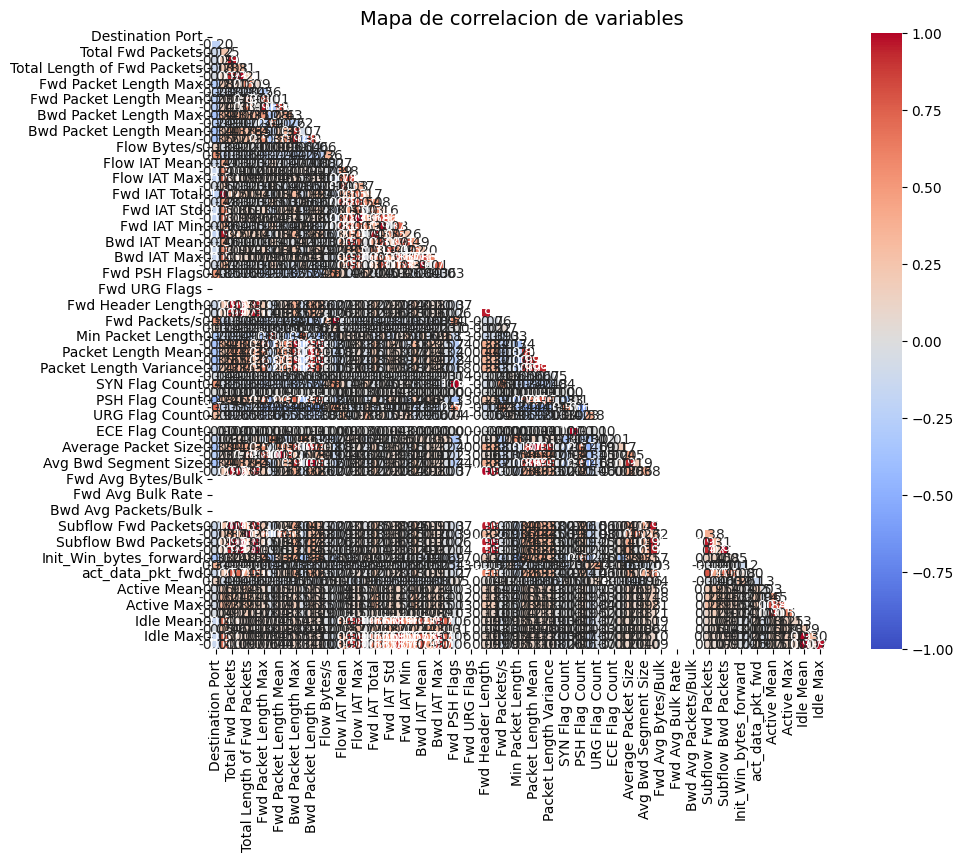

In [ ]:
plt.figure(figsize=(10, 8))

corr_matrix = monday_v1.drop('Label', axis=1).corr()

# Máscara para ocultar el triángulo superior (que es redundante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            mask=mask, 
            vmin=-1, vmax=1)

plt.title('Mapa de correlacion de variables', fontsize=14)
plt.show()

##### Filtro de matriz por pares de variables con fuerte relacion entre si ( mayores a THRESHOLD )

Pares de variables altamente correlacionadas (>0.9): 67 
--------------------------------------------------
Fwd IAT Total          Flow Duration             0.997345
Packet Length Mean     Average Packet Size       0.996419
Flow Packets/s         Fwd Packets/s             0.993715
Fwd IAT Max            Flow IAT Max              0.992835
Idle Max               Idle Mean                 0.992574
                                                   ...   
Active Min             Active Mean               0.908688
Bwd Packet Length Max  Avg Bwd Segment Size      0.905746
                       Bwd Packet Length Mean    0.905746
Idle Mean              Flow IAT Std              0.905188
Max Packet Length      Bwd Packet Length Std     0.904011
Length: 67, dtype: float64


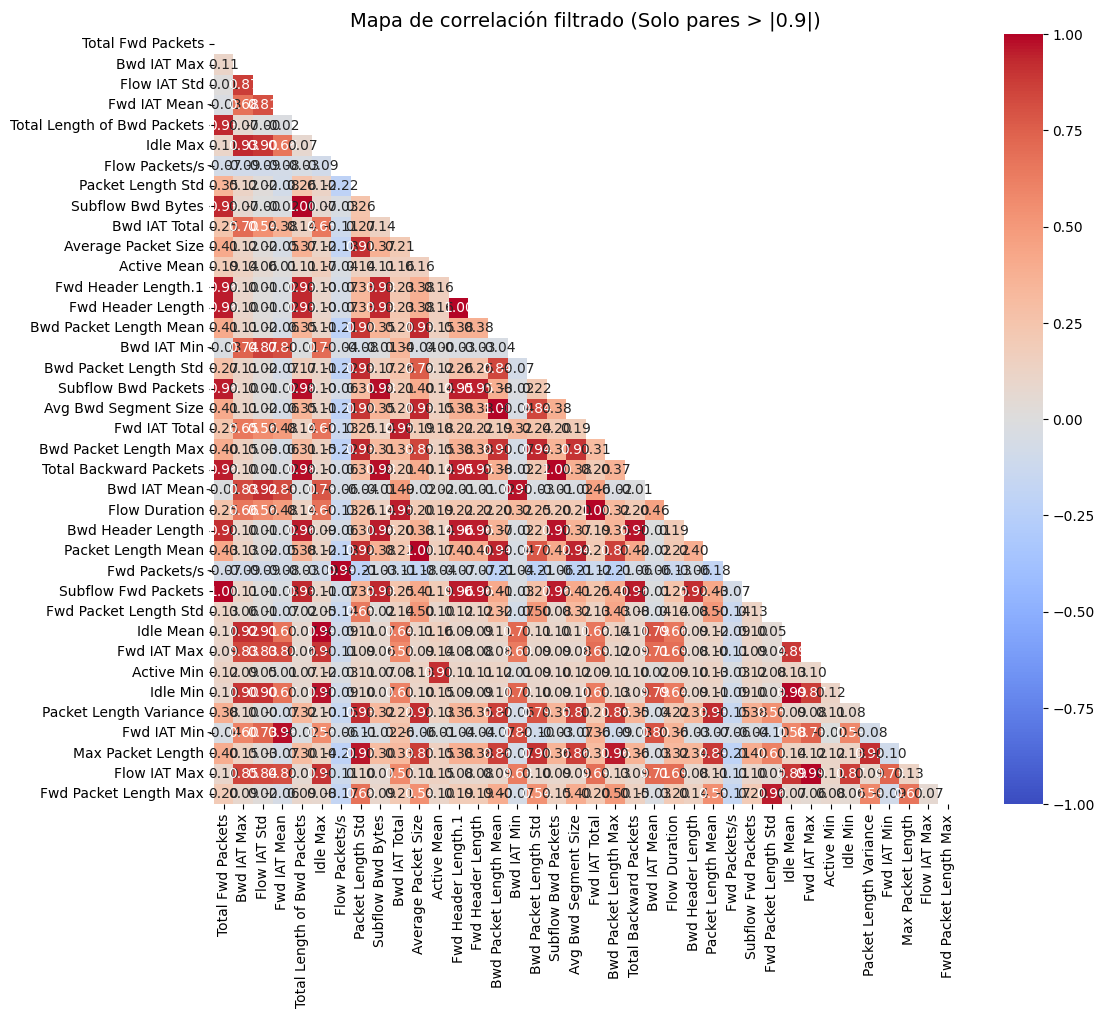

In [ ]:
THRESHOLD = 0.90

corr_pairs = corr_matrix.unstack()

sorted_pairs = corr_pairs.sort_values(key=abs, ascending=False)

strong_pairs = sorted_pairs[(abs(sorted_pairs) > THRESHOLD) & (sorted_pairs != 1.0)][::2]

print(f"Pares de variables altamente correlacionadas (>{THRESHOLD}): {len(strong_pairs)} ")
print("-" * 50)
print(strong_pairs)

features_to_plot = set()
for var1, var2 in strong_pairs.index:
    features_to_plot.add(var1)
    features_to_plot.add(var2)

features_to_plot = list(features_to_plot)

filtered_corr_matrix = monday_v1.drop('Label', axis=1)[features_to_plot].corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(filtered_corr_matrix, dtype=bool))

sns.heatmap(filtered_corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            mask=mask, 
            vmin=-1, vmax=1,
            annot_kws={"size": 10})

plt.title(f'Mapa de correlación filtrado (Solo pares > |{THRESHOLD}|)', fontsize=14)
plt.show()

#### Las siguientes columnas se descartan por razones documentadas
###### (Sharafaldin et al., 2018; Panigrahi & Borah, 2018; Engelen et al., 2021 — "Troubleshooting an Intrusion Detection Dataset")

- Duplicados por construcción de CICFlowMeter: `Fwd Header Length.1` es copia
   literal de `Fwd Header Length`; `Avg Fwd/Bwd Segment Size` coinciden con
   `Fwd/Bwd Packet Length Mean`; las `Subflow *` son idénticas a las `Total *`
   cuando el flujo tiene un único subflujo (caso casi universal)

- Features `Bulk`: el detector de ráfagas de CICFlowMeter rara vez se activa
   en tráfico TCP/HTTP, por lo que son ~0 en todo el dataset

- Flags TCP poco usadas (`Bwd PSH`, `Fwd/Bwd URG`, `CWE`): valores constantes
   o casi constantes, sin señal discriminativa

- `Destination Port`: Para el modelo LSTM, al ser un entero nominal y no ordinal, contamina la señal

In [ ]:
duplicated = [
    'Fwd Header Length.1',
    'Avg Fwd Segment Size',
    'Avg Bwd Segment Size',
    'Subflow Fwd Packets',
    'Subflow Fwd Bytes',
    'Subflow Bwd Packets',
    'Subflow Bwd Bytes',
]

In [ ]:
bulk_cols = [
    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate',
]

monday_v1[bulk_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Fwd Avg Bytes/Bulk,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Fwd Avg Packets/Bulk,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Fwd Avg Bulk Rate,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bwd Avg Bytes/Bulk,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bwd Avg Packets/Bulk,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bwd Avg Bulk Rate,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
constantes = ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count']

monday_v1[constantes].describe().T

,count,mean,std,min,25%,50%,75%,max
Bwd PSH Flags,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Fwd URG Flags,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bwd URG Flags,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CWE Flag Count,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
monday_v2 = monday_v1.drop(columns=duplicated + bulk_cols + constantes + ['Destination Port'])

In [ ]:
monday_v1.shape

(50000, 79)

In [ ]:
monday_v2.shape

(50000, 61)

In [ ]:
# Aplico mismo drop para el wednesday dataset

wednesday_v2 = wednesday_v1.drop(columns=duplicated + bulk_cols + constantes + ['Destination Port'])

In [ ]:
wednesday_v1.shape

(50000, 79)

In [ ]:
wednesday_v2.shape

(50000, 61)

In [ ]:
corr_matrix = monday_v2.drop('Label', axis=1).corr()

Pares de variables altamente correlacionadas (>0.9): 42 
--------------------------------------------------
Fwd IAT Total                Flow Duration                  0.997345
Packet Length Mean           Average Packet Size            0.996419
Fwd Packets/s                Flow Packets/s                 0.993715
Flow IAT Max                 Fwd IAT Max                    0.992835
Idle Max                     Idle Mean                      0.992574
Idle Min                     Idle Mean                      0.992409
Fwd IAT Min                  Fwd IAT Mean                   0.978134
Total Backward Packets       Total Length of Bwd Packets    0.977158
                             Bwd Header Length              0.973743
Bwd IAT Mean                 Bwd IAT Min                    0.972621
Idle Min                     Idle Max                       0.971118
Packet Length Std            Max Packet Length              0.968575
Max Packet Length            Bwd Packet Length Max          0.96

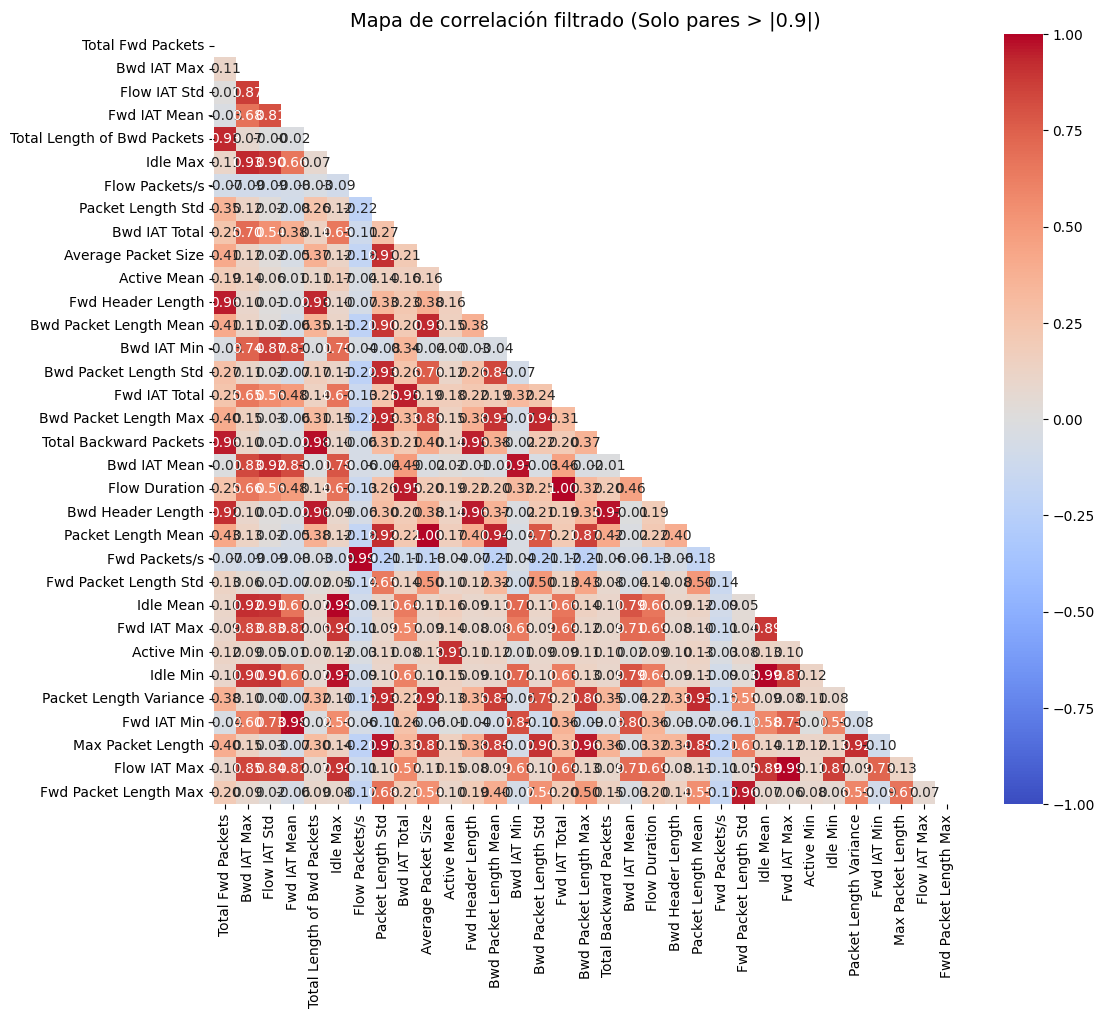

In [ ]:
THRESHOLD = 0.90

corr_pairs = corr_matrix.unstack()

sorted_pairs = corr_pairs.sort_values(key=abs, ascending=False)

strong_pairs = sorted_pairs[(abs(sorted_pairs) > THRESHOLD) & (sorted_pairs != 1.0)][::2]

print(f"Pares de variables altamente correlacionadas (>{THRESHOLD}): {len(strong_pairs)} ")
print("-" * 50)
print(strong_pairs)

features_to_plot = set()
for var1, var2 in strong_pairs.index:
    features_to_plot.add(var1)
    features_to_plot.add(var2)

features_to_plot = list(features_to_plot)

filtered_corr_matrix = monday_v2.drop('Label', axis=1)[features_to_plot].corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(filtered_corr_matrix, dtype=bool))

sns.heatmap(filtered_corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            mask=mask, 
            vmin=-1, vmax=1,
            annot_kws={"size": 10})

plt.title(f'Mapa de correlación filtrado (Solo pares > |{THRESHOLD}|)', fontsize=14)
plt.show()

In [ ]:
# Lista final de features a eliminar tras inspección manual de los 42 pares
# con threshold (p) ≥ 0.9 y del heatmap filtrado. Para cada cluster se conserva la variable
# más interpretable frente a sus pares correlacionados

# Comparación realizada con IA:
# Se usó la Inteligencia Artificial (Claude) para detectar las variables mas representativas en un contexto de Ciberseguridad.

drop_cols = [
    # Duración del flujo. 'Flow Duration' es la métrica más
    # directa; los totales de IAT son reformulaciones equivalentes.
    'Fwd IAT Total',               # ρ=0.997 con Flow Duration
    'Bwd IAT Total',               # ρ=0.954 con Flow Duration

    # Estadísticas de tamaño de paquete. 'Average Packet Size'
    # es el nombre más interpretable y absorbe a medias, std, varianza, máx,
    # y los equivalentes Bwd.
    'Packet Length Mean',          # ρ=0.996 con Average Packet Size
    'Packet Length Std',           # ρ=0.913 con Average Packet Size
    'Packet Length Variance',      # ρ=0.919 con Average Packet Size
    'Max Packet Length',           # ρ=0.969 con Packet Length Std
    'Bwd Packet Length Max',       # ρ=0.960 con Max Packet Length
    'Bwd Packet Length Mean',      # ρ=0.931 con Average Packet Size
    'Bwd Packet Length Std',       # ρ=0.927 con Packet Length Std

    # Tasa de paquetes. 'Fwd Packets/s' ya refleja la tasa global.
    'Flow Packets/s',              # ρ=0.994 con Fwd Packets/s

    # Máximo IAT. 'Flow IAT Max' es más general que su versión Fwd.
    'Fwd IAT Max',                 # ρ=0.993 con Flow IAT Max

    # Métricas de inactividad e IAT backward. 'Idle Max' captura
    # la pausa más larga del flujo, señal clave para ataques lentos
    # (slowloris, Slowhttptest). El resto son medias/mín menos importantes.
    'Idle Mean',                   # ρ=0.993 con Idle Max
    'Idle Min',                    # ρ=0.971 con Idle Max
    'Bwd IAT Max',                 # ρ=0.932 con Idle Max
    'Bwd IAT Mean',                # ρ=0.972 con Bwd IAT Min / ρ=0.920 con Flow IAT Std
    'Bwd IAT Min',                 # ρ=0.972 con Bwd IAT Mean
    'Flow IAT Std',                # ρ=0.920 con Bwd IAT Mean / ρ=0.905 con Idle Mean

    # IAT forward medio. 'Fwd IAT Mean' resume mín y media.
    'Fwd IAT Min',                 # ρ=0.978 con Fwd IAT Mean

    # Conteo de paquetes y longitud de cabeceras. 'Total Fwd packets' 
    # es la métrica más interpretable para RCA (paquetes enviados
    # por el atacante); las demás miden lo mismo desde otra dirección.
    'Total Backward Packets',      # ρ=0.958 con Total Fwd Packets
    'Total Length of Bwd Packets', # ρ=0.931 con Total Fwd Packets
    'Fwd Header Length',           # ρ=0.960 con Total Fwd Packets
    'Bwd Header Length',           # ρ=0.917 con Total Fwd Packets

    # Tamaño de paquete forward. Conservamos el máximo.
    'Fwd Packet Length Std',       # ρ=0.958 con Fwd Packet Length Max

    # Tiempo activo. 'Active Mean' resume a 'Active Min'.
    'Active Min',                  # ρ=0.909 con Active Mean
]

monday_v3    = monday_v2.drop(columns=drop_cols, errors='ignore')
wednesday_v3 = wednesday_v2.drop(columns=drop_cols, errors='ignore')

assert list(monday_v3.columns) == list(wednesday_v3.columns)
print(f"Features finales: {monday_v3.shape}")

Features finales: (50000, 37)


In [ ]:
corr_matrix = monday_v3.drop('Label', axis=1).corr()

Pares de variables altamente correlacionadas (>0.9): 0 
--------------------------------------------------
Series([], dtype: float64)


/Users/esemb/Desktop/code/cei/dl/.venv/lib/python3.13/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/Users/esemb/Desktop/code/cei/dl/.venv/lib/python3.13/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


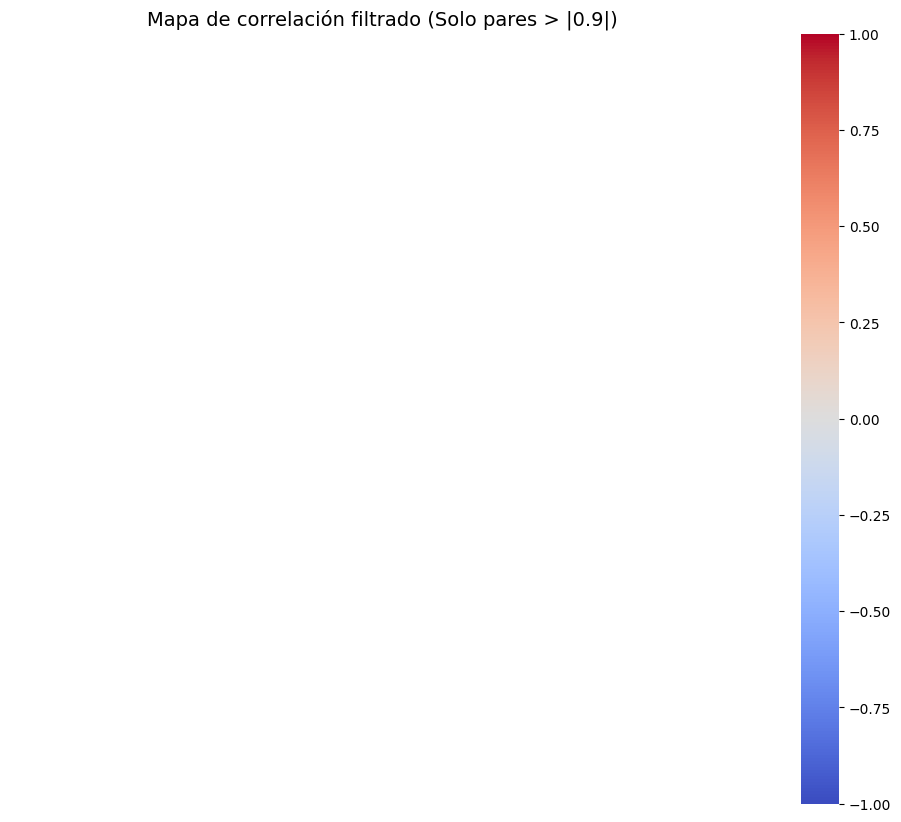

In [ ]:
# Ultimo chequeo de correlacion de variables

THRESHOLD = 0.90

corr_pairs = corr_matrix.unstack()

sorted_pairs = corr_pairs.sort_values(key=abs, ascending=False)

strong_pairs = sorted_pairs[(abs(sorted_pairs) > THRESHOLD) & (sorted_pairs != 1.0)][::2]

print(f"Pares de variables altamente correlacionadas (>{THRESHOLD}): {len(strong_pairs)} ")
print("-" * 50)
print(strong_pairs)

features_to_plot = set()
for var1, var2 in strong_pairs.index:
    features_to_plot.add(var1)
    features_to_plot.add(var2)

features_to_plot = list(features_to_plot)

filtered_corr_matrix = monday_v3.drop('Label', axis=1)[features_to_plot].corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(filtered_corr_matrix, dtype=bool))

sns.heatmap(filtered_corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            mask=mask, 
            vmin=-1, vmax=1,
            annot_kws={"size": 10})

plt.title(f'Mapa de correlación filtrado (Solo pares > |{THRESHOLD}|)', fontsize=14)
plt.show()

In [ ]:
X_monday = monday_v3.drop('Label', axis=1)
y_monday = monday_v3['Label']

In [ ]:
X_wednesday = wednesday_v3.drop('Label', axis=1)
y_wednesday = wednesday_v3['Label']

In [ ]:
X_monday.describe()

,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Bwd Packet Length Min,Flow Bytes/s,Flow IAT Mean,Flow IAT Max,...,Average Packet Size,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Idle Std,Idle Max
count,5.000000e+04,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04
mean,1.119120e+07,7.970600,700.752040,295.35044,13.247480,63.971628,29.223980,2.248919e+06,1.562626e+06,5.240368e+06,...,148.975480,17507.436000,3730.846820,4.571800,26.580260,7.135285e+04,4.224182e+04,1.436781e+05,2.077538e+05,3.872326e+06
std,2.885670e+07,27.138807,2271.152683,481.75022,24.827008,99.928797,62.038141,2.299028e+07,7.022846e+06,1.511135e+07,...,193.693082,24768.919485,10573.785049,18.942072,6.321332,6.309569e+05,3.809421e+05,1.008832e+06,2.156399e+06,1.396583e+07
min,-1.000000e+00,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-1.200000e+07,-1.000000e+00,-1.000000e+00,...,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.290000e+02,2.000000,37.000000,31.00000,0.000000,18.500000,0.000000,1.366224e+02,1.370000e+02,2.040000e+02,...,31.000000,9.250000,-1.000000,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.777050e+04,2.000000,74.000000,50.00000,0.000000,45.571429,0.000000,3.742032e+03,2.309502e+04,5.029750e+04,...,87.500000,1120.000000,30.000000,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.466563e+06,10.000000,825.000000,469.00000,30.000000,72.500000,23.000000,3.275553e+04,2.557868e+05,2.788363e+06,...,184.000000,29200.000000,349.000000,5.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.199994e+08,2315.000000,117230.000000,13140.00000,1448.000000,2670.166667,2146.000000,2.071000e+09,1.143926e+08,1.198671e+08,...,2068.000000,65535.000000,65535.000000,1124.000000,93.000000,5.625134e+07,2.228729e+07,5.625134e+07,6.941803e+07,1.198671e+08


In [ ]:
X_wednesday.describe()

,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Bwd Packet Length Min,Flow Bytes/s,Flow IAT Mean,Flow IAT Max,...,Average Packet Size,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Idle Std,Idle Max
count,5.000000e+04,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,...,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04
mean,3.086187e+07,6.744540,771.08452,292.613620,23.194080,94.643847,19.216900,6.277495e+06,3.604395e+06,2.208391e+07,...,392.339452,12411.43974,1968.179580,3.380980,28.570720,5.944165e+05,2.094734e+05,7.912344e+05,1.477040e+06,2.094297e+07
std,4.301710e+07,25.358373,6358.73769,569.693581,144.812075,206.815139,51.480131,6.451586e+07,6.679057e+06,3.547552e+07,...,493.965819,14823.52871,7932.412742,20.307225,6.670026,1.881295e+06,1.092842e+06,2.432302e+06,5.157767e+06,3.564997e+07
min,1.000000e+00,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,5.000000e-01,1.000000e+00,...,0.000000,-1.00000,-1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.063975e+04,2.000000,12.00000,7.000000,0.000000,6.000000,0.000000,1.382574e+01,1.109166e+04,2.645400e+04,...,9.000000,229.00000,-1.000000,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.372878e+06,3.000000,288.00000,187.000000,0.000000,48.000000,0.000000,2.769459e+02,1.782067e+05,9.999595e+05,...,121.000000,395.00000,110.000000,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,6.340977e+07,7.000000,441.00000,358.000000,6.000000,105.200000,0.000000,2.831154e+04,6.112513e+06,3.210000e+07,...,849.875000,29200.00000,235.000000,2.000000,32.000000,5.297000e+03,0.000000e+00,5.297000e+03,0.000000e+00,3.210000e+07
max,1.200000e+08,1465.000000,463399.00000,10136.000000,1983.000000,2898.750000,1983.000000,2.070000e+09,1.190000e+08,1.200000e+08,...,2068.000000,65535.00000,65535.000000,1439.000000,56.000000,6.800000e+07,7.000000e+07,9.900000e+07,6.280000e+07,1.200000e+08


In [ ]:
y_wednesday.value_counts(normalize=True).mul(100).round()

Label
BENIGN              51.0
DoS Hulk            30.0
DoS Slowhttptest    11.0
DoS slowloris        8.0
Name: proportion, dtype: float64

In [ ]:
scaler = StandardScaler()

X_monday_s = X_monday.copy()
X_wednesday_s = X_wednesday.copy()

X_monday_s = scaler.fit_transform(X_monday)
X_wednesday_s = scaler.transform(X_wednesday)

In [ ]:
type(X_monday_s)

numpy.ndarray

In [ ]:
print(f"Media Monday: {np.abs(X_monday_s.mean()):.6f}")
print(f"Std Monday: {np.abs(X_monday_s.std())}")

Media Monday: 0.000000
Std Monday: 1.0


In [ ]:
print(f"Media Wednesday: {np.abs(X_wednesday_s.mean()):.6f}")
print(f"Std Wednesday: {np.abs(X_wednesday_s.std())}")

Media Wednesday: 0.300731
Std Wednesday: 2.1614635570514174


#### Observación `X_monday_s` vs `X_wednesday_s`

- el scaler captura la distribución del tráfico benigno (monday), por lo tanto la distribución de wednesday se aleja del rango [-1, 1] ya que contiene anomalias
- esta desviación es precisamente la señal que el modelo LSTM Autoencoder tiene que detectar como error de reconstrucción elevado

#### Entrenamiento de modelo XGBoost (Supervisado)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_wednesday_s, y_wednesday, test_size=0.3, stratify=y_wednesday, random_state=42)

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [ ]:
le.classes_

array(['BENIGN', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris'],
      dtype=object)

In [ ]:
y_train.value_counts()

Label
BENIGN              17840
DoS Hulk            10421
DoS Slowhttptest     3849
DoS slowloris        2890
Name: count, dtype: int64

In [ ]:
# Pesos de muestra inversamente proporcionales a la frecuencia de cada clase
# Corrige el desbalance entre BENIGN (~28k) y ataques minoritarios (slowloris ~2.5k, Slowhttptest ~5.5k)
# Sin esto, XGBoost optimiza para la clase mayoritaria a expensas de las minoritarias
# Referencia: Chen & Guestrin (2016), XGBoost: A Scalable Tree Boosting System
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=30, # 200, 100, 50
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    objective='multi:softprob',
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train_enc, sample_weight=sample_weights, eval_set=[(X_train, y_train_enc), (X_test, y_test_enc)])

# Referencia: "Introduction to Boosted Trees" https://xgboost.readthedocs.io/en/release_3.2.0/tutorials/xgb_model.html

[0]	validation_0-mlogloss:1.21320	validation_1-mlogloss:1.21414
[1]	validation_0-mlogloss:1.07210	validation_1-mlogloss:1.07367
[2]	validation_0-mlogloss:0.95357	validation_1-mlogloss:0.95565
[3]	validation_0-mlogloss:0.84960	validation_1-mlogloss:0.85185
[4]	validation_0-mlogloss:0.76093	validation_1-mlogloss:0.76326
[5]	validation_0-mlogloss:0.68345	validation_1-mlogloss:0.68575
[6]	validation_0-mlogloss:0.61438	validation_1-mlogloss:0.61659
[7]	validation_0-mlogloss:0.55390	validation_1-mlogloss:0.55603
[8]	validation_0-mlogloss:0.50067	validation_1-mlogloss:0.50270
[9]	validation_0-mlogloss:0.45383	validation_1-mlogloss:0.45587
[10]	validation_0-mlogloss:0.41212	validation_1-mlogloss:0.41416
[11]	validation_0-mlogloss:0.37490	validation_1-mlogloss:0.37696
[12]	validation_0-mlogloss:0.34132	validation_1-mlogloss:0.34339
[13]	validation_0-mlogloss:0.31110	validation_1-mlogloss:0.31318
[14]	validation_0-mlogloss:0.28195	validation_1-mlogloss:0.28381
[15]	validation_0-mlogloss:0.25594	

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
y_pred_enc = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)
y_test_str = le.inverse_transform(y_test_enc)

print(classification_report(y_test_str, y_pred))

                  precision    recall  f1-score   support

          BENIGN       1.00      0.99      1.00      7645
        DoS Hulk       0.99      1.00      1.00      4466
DoS Slowhttptest       0.99      0.99      0.99      1650
   DoS slowloris       0.99      1.00      0.99      1239

        accuracy                           1.00     15000
       macro avg       0.99      1.00      1.00     15000
    weighted avg       1.00      1.00      1.00     15000



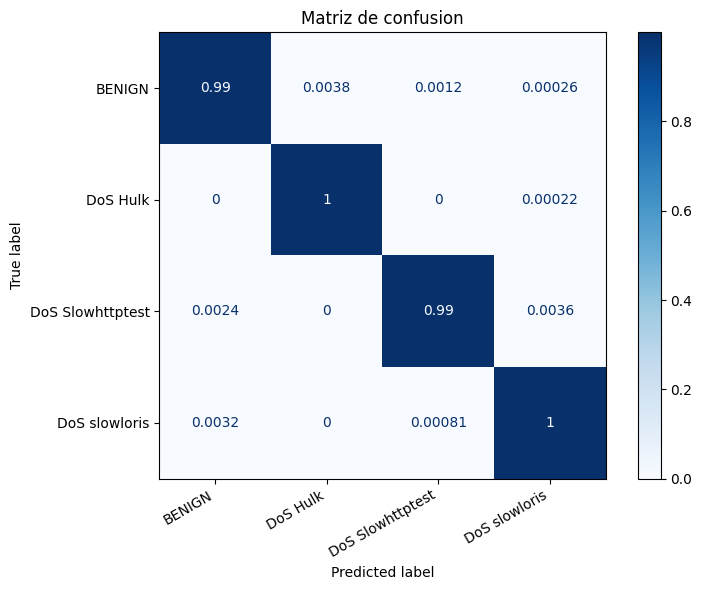

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_str, y_pred,
    display_labels=le.classes_,
    normalize='true',
    cmap='Blues',
    ax=ax
)
plt.title('Matriz de confusion')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

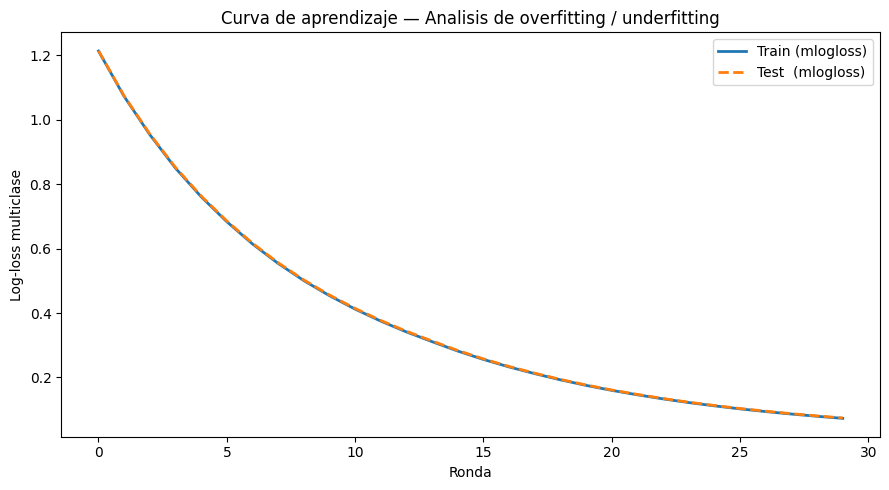

In [ ]:
results   = xgb_model.evals_result()
train_loss = results['validation_0']['mlogloss']
test_loss  = results['validation_1']['mlogloss']

plt.figure(figsize=(9, 5))
plt.plot(train_loss, label='Train (mlogloss)', linewidth=2)
plt.plot(test_loss,  label='Test  (mlogloss)', linewidth=2, linestyle='--')
plt.xlabel('Ronda')
plt.ylabel('Log-loss multiclase')
plt.title('Curva de aprendizaje — Analisis de overfitting / underfitting')
plt.legend()
plt.tight_layout()
plt.show()

#### Entrenamiento de modelo LSTM Autoencoder (No Supervisado)

- Detección de secuencias anómalas


In [ ]:
# La LSTM RNN requiere un input con las siguientes dimensiones: muestras, pasos_temporales y features
# El array actual (50000, 36) se debe transformar en una coleccion de sub-secuencias
# consecutivas de longitud WINDOW_SIZE mediante una ventana deslizante
# con stride=1 (cada nueva muestra se desplaza una posición)
#
# Tamaño de ventana (20): valor recomendado en la documentacion de deteccion
# de anomalias sobre flujos de red. Suficientemente largo para capturar
# patrones de rafagas (bursts) tipicos de ataques DoS, y suficientemente
# corto para mantener el coste computacional bajo

# Entrada original: (50000, 36)
# Entrada para el LSTM: (49981, 20, 36) — cada muestra es una secuencia de 20 flujos consecutivos

# Referencia: Malhotra et al. (2016), ICML Anomaly Detection Workshop.
# Uso de LLM Claude para entender y definir la estructura de la función

WINDOW_SIZE = 20

def make_windows(X, window=WINDOW_SIZE):
    """
    Convierte una matriz (N, F) en un tensor (N - window + 1, window, F)
    de ventanas deslizantes consecutivas con stride=1.
    """
    n_samples = X.shape[0] - window + 1
    return np.stack([X[i:i + window] for i in range(n_samples)])


# Construcción de ventanas para entrenamiento (Monday) y evaluación (Wednesday)
X_monday_windows    = make_windows(X_monday_s)
X_wednesday_windows = make_windows(X_wednesday_s)

print(f"Shape original Monday:      {X_monday_s.shape}")
print(f"Shape ventanas Monday:      {X_monday_windows.shape}")
print(f"Shape original Wednesday:   {X_wednesday_s.shape}")
print(f"Shape ventanas Wednesday:   {X_wednesday_windows.shape}")

Shape original Monday:      (50000, 36)
Shape ventanas Monday:      (49981, 20, 36)
Shape original Wednesday:   (50000, 36)
Shape ventanas Wednesday:   (49981, 20, 36)


In [ ]:
# Verificación: la primera ventana debe coincidir con las primeras 20 filas originales
assert np.allclose(X_monday_windows[0], X_monday_s[0:20])
# La segunda ventana debe coincidir con las filas 1 a 20
assert np.allclose(X_monday_windows[1], X_monday_s[1:21])
print("Ventanas correctamente construidas.")

Ventanas correctamente construidas.


In [ ]:
## Split entrenamiento / validacion (80/20)

SPLIT = 0.80

total_m = X_monday_windows.shape[0]
train_m = int(total_m * SPLIT)
print(f'Total: {total_m}, Train: {train_m}')

Total: 49981, Train: 39984


In [ ]:
## Dividimos las ventanas en train y val
X_train_lstm = X_monday_windows[:train_m]
X_val_lstm = X_monday_windows[train_m:]
print(f'Train shape: {X_train_lstm.shape}, Val shape: {X_val_lstm.shape}')

Train shape: (39984, 20, 36), Val shape: (9997, 20, 36)


#### Arquitectura del modelo

- Definición: LSTM Autoencoder
- Consiste en un encoder LSTM que transorma cada ventana temporal de 20 flujos de red consecutivos en un vector de activacion
- Este vector se comprime luego mediante una capa densa a un espacio latente de 32 dimensiones
- Una vez comprimido, un RepeatVector actua como "puente" que reconstruye la dimension temporal/secuencial replicando el vector comprimido 20 veces en nuestro caso
- El decoder, también LSTM, reconstruye la secuencia paso a paso
- Finalmente una capa densa de tipo TimeDistributed(Dense) proyecta cada paso temporal denuevo a las 36 features originales

###### * Propuesto por Malhotra et al. (2016) para detección de anomalías en series temporales multivariadas

In [ ]:
features = X_monday_windows.shape[2]

In [ ]:
inputs = Input(shape=(WINDOW_SIZE, features))

encoded = LSTM(64, activation='tanh', return_sequences=False)(inputs) ## output: un solo vector que resume toda la secuencia

bottleneck = Dense(32, activation='relu')(encoded)

repeated = RepeatVector(WINDOW_SIZE)(bottleneck)

decoded = LSTM(64, activation='tanh', return_sequences=True)(repeated) ## output: un vector por cada paso (reconstruye toda la secuencia completa)

outputs = TimeDistributed(Dense(features))(decoded)

lstm_model = Model(inputs=inputs, outputs=outputs)
lstm_model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 20, 36)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 20, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 36)         │         2,340 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,108 (215.27 KB)

 Trainable params: 55,108 (215.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='mae'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_lstm, X_train_lstm,        # input = target (autoencoder)
    epochs=50,
    batch_size=256,
    validation_data=(X_val_lstm, X_val_lstm),
    callbacks=[early_stop],
    shuffle=False,               # preservar orden temporal
    verbose=1
)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 0.3740 - val_loss: 0.3205
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.3360 - val_loss: 0.3112
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.3298 - val_loss: 0.3075
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.3262 - val_loss: 0.3061
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.3241 - val_loss: 0.3050
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.3219 - val_loss: 0.3038
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.3206 - val_loss: 0.3034
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.3196 - val_loss: 0.3031
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.3188 - val_loss: 0.3024
Epoch 10/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.3180 - val_loss: 0.3016
Epoch 11/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.3173 - val_loss: 0.3015
Epoch 12/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 

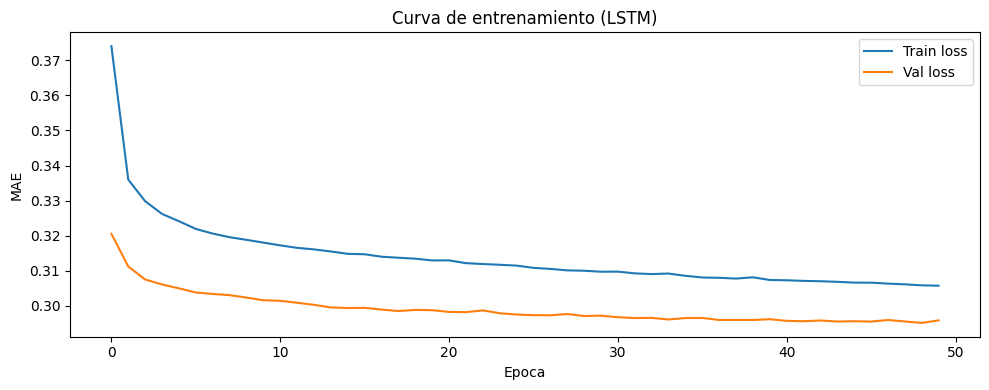

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoca')
plt.ylabel('MAE')
plt.title('Curva de entrenamiento (LSTM)')
plt.legend()
plt.tight_layout()
plt.show()

#### Observación
- El modelo convergió sin signos de sobreajuste, train y val loss quedaron muy cerca durante todo el entrenamiento. El error de reconstrucción sobre estos datos (tráfico benigno) nos va a servir para detectar futuras anomalias


In [ ]:
# Ahora, evalúo el error de reconstruccion sobre los datos del miercoles (X_wednesday_windows)

X_wednesday_pred = lstm_model.predict(X_wednesday_windows, batch_size=256, verbose=1)

reconstruction_errors = np.mean(np.abs(X_wednesday_windows - X_wednesday_pred), axis=(1,2))

print(f'Shape X_wednesday_pred: {X_wednesday_pred.shape}')
print(f'Shape reconstruction_errors: {reconstruction_errors.shape}')

196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
Shape X_wednesday_pred: (49981, 20, 36)
Shape reconstruction_errors: (49981,)


In [ ]:
print(f"Error min: {reconstruction_errors.min():.4f}")
print(f"Error max: {reconstruction_errors.max():.4f}")
print(f"Error medio: {reconstruction_errors.mean():.4f}")

Error min: 0.0516
Error max: 4.2941
Error medio: 0.5712


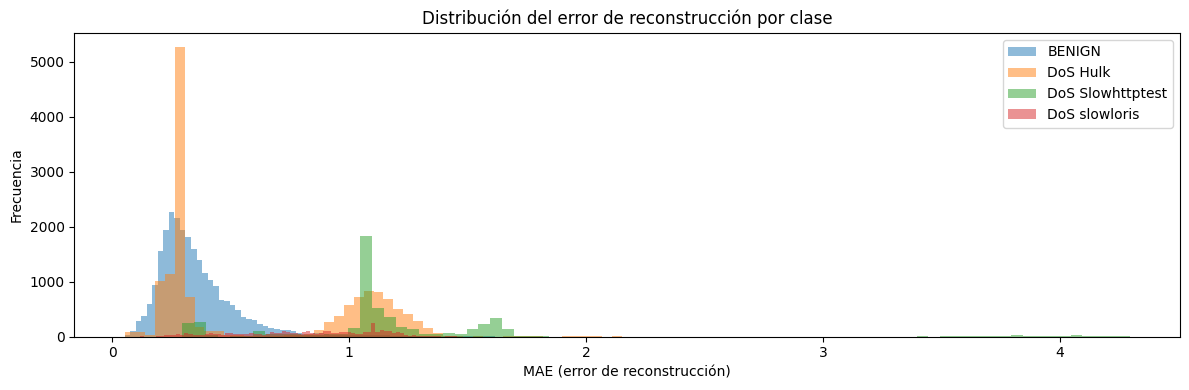

In [ ]:
y_windows = y_wednesday.values[WINDOW_SIZE - 1:] # Alineo labels con ventanas (shape 49981)

plt.figure(figsize=(12, 4))
for label in np.unique(y_windows):
    mask = y_windows == label
    plt.hist(reconstruction_errors[mask], bins=80, alpha=0.5, label=label)

plt.xlabel('MAE (error de reconstrucción)')
plt.ylabel('Frecuencia')
plt.title('Distribución del error de reconstrucción por clase')
plt.legend()
plt.tight_layout()
plt.show()

En este histograma podemos ver una separacion clara de "DoS Slowhttptest" y "DoS slowloris". Ahora, tambien se observa como "DoS Hulk" se solapa con "BENIGN" (trafico benigno). La razon se puede justificar por una razon espeficia del tipo de ataque que "DoS Hulk" comete: genera HTTP requests aparentemente validos que a nivel de features no son distintas al trafico normal. 

In [ ]:
# Error de reconstrucción sobre el set de validación benigno
X_val_pred = lstm_model.predict(X_val_lstm, batch_size=256, verbose=0)
val_errors = np.mean(np.abs(X_val_lstm - X_val_pred), axis=(1, 2))

# Umbral en percentil 95: todo lo que tenga un error de reconstrucción mayor a este umbral lo marcamos como anomalía
THRESHOLD = np.percentile(val_errors, 95)

print(f"Error medio (validación benigna): {val_errors.mean():.4f}")
print(f"Umbral (percentil 95): {THRESHOLD:.4f}")

Error medio (validación benigna): 0.2952
Umbral (percentil 95): 0.4426


In [ ]:
# Convierto el problema a binario: BENIGN=0, cualquier ataque=1
# Las predicciones surgen de comparar el error de reconstrucción
# de cada ventana de Wednesday contra el umbral calibrado en la celda anterior

y_binary = (y_windows != 'BENIGN').astype(int)  # 0=benigno, 1=ataque

# Predicciones binarias del LSTM
y_pred_binary = (reconstruction_errors > THRESHOLD).astype(int)

print(classification_report(y_binary, y_pred_binary, target_names=['BENIGN', 'ATAQUE']))


              precision    recall  f1-score   support

      BENIGN       0.67      0.78      0.72     25466
      ATAQUE       0.73      0.60      0.66     24515

    accuracy                           0.69     49981
   macro avg       0.70      0.69      0.69     49981
weighted avg       0.70      0.69      0.69     49981



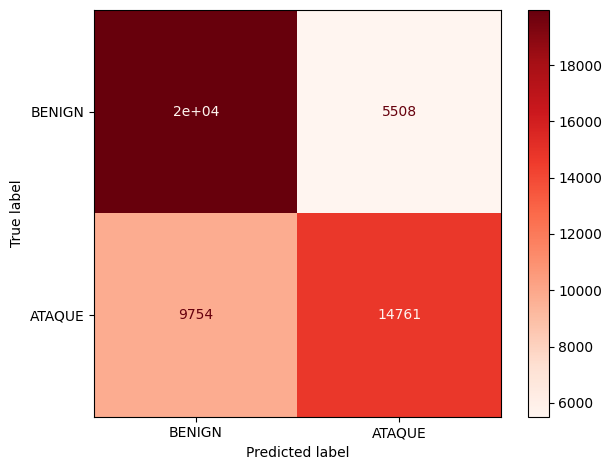

In [ ]:
# Matriz de confusion

cm = confusion_matrix(y_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN', 'ATAQUE'])
disp.plot(cmap='Reds')
plt.tight_layout()
plt.show()

#### Integracion LSTM con XGBoost

Ahora conectamos las dos etapas:

- LSTM marca una ventana como anómala (error > umbral)
- Tomamos el último flujo de esa ventana como representación
- XGBoost clasifica qué tipo de ataque esa

In [ ]:
anomaly_idx = np.where(y_pred_binary == 1)[0] # indices de ventanas detectadas como anómalas

print(f"Ventanas anómalas detectadas: {len(anomaly_idx)}, shape del dataset: {X_wednesday_windows.shape}")

Ventanas anómalas detectadas: 20269, shape del dataset: (49981, 20, 36)


In [ ]:
X_anomalies = X_wednesday_windows[anomaly_idx, -1, :] # ultimo timestep de cada ventana anómala → (N, 36). * una fila por ventana anómala

y_anomalies_true = y_windows[anomaly_idx] # Labels reales

print(f"Shape entrada XGBoost: {X_anomalies.shape}")

Shape entrada XGBoost: (20269, 36)


In [ ]:
# Predicción XGBoost
y_anomalies_pred = le.inverse_transform(xgb_model.predict(X_anomalies)) # inverse_transform usado para convertir devuelta a texto cada ataque

In [ ]:
print(classification_report(y_anomalies_true, y_anomalies_pred))

                  precision    recall  f1-score   support

          BENIGN       1.00      0.99      1.00      5508
        DoS Hulk       1.00      1.00      1.00      6252
DoS Slowhttptest       1.00      0.99      1.00      4967
   DoS slowloris       0.99      1.00      1.00      3542

        accuracy                           1.00     20269
       macro avg       1.00      1.00      1.00     20269
    weighted avg       1.00      1.00      1.00     20269



#### Observaciones

- XGBoost clasifico las 20.269 ventanas que el LSTM marco como anomalas con muy buena precision
- Los 5.508 falsos positivos del LSTM se clasificaron finalmente como BENIGN -- podriamos decir que se autocorrigieron
- Los ataques que llegaron (hay varios que lamentablemente no pasaron el umbral de LSTM) fueron clasificados correctamente
- Una de las limitaciones es que hay 9.750 flujos de DoS Hulk que nunca fueron evaluados por la solapación con los ataques benignos explicada previamente. 

In [ ]:
# Metricas finales

# Predicción final por ventana:
#   - LSTM dice benigno → predicción final = 'BENIGN'
#   - LSTM dice anómalo → XGBoost clasifica el tipo de ataque

# asumo que todo es benigno
y_final_pred = ['BENIGN'] * len(y_windows)
y_final_pred = np.array(y_final_pred, dtype=object)
print(f"Total ventanas a clasificar: {len(y_final_pred)}")


Total ventanas a clasificar: 49981


In [ ]:
y_final_pred[:5]

array(['BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN'], dtype=object)

In [ ]:
y_anomalies_pred[15000:15005]

array(['DoS Hulk', 'DoS Hulk', 'DoS Hulk', 'DoS Hulk', 'DoS Hulk'],
      dtype=object)

In [ ]:
# remplazo los anómalos con la clasificación previa del XGBoost
y_final_pred[anomaly_idx] = y_anomalies_pred

In [ ]:
print(classification_report(y_windows, y_final_pred))

                  precision    recall  f1-score   support

          BENIGN       0.72      1.00      0.84     25466
        DoS Hulk       1.00      0.42      0.59     14887
DoS Slowhttptest       1.00      0.90      0.95      5499
   DoS slowloris       0.99      0.86      0.92      4129

        accuracy                           0.80     49981
       macro avg       0.93      0.79      0.82     49981
    weighted avg       0.86      0.80      0.78     49981



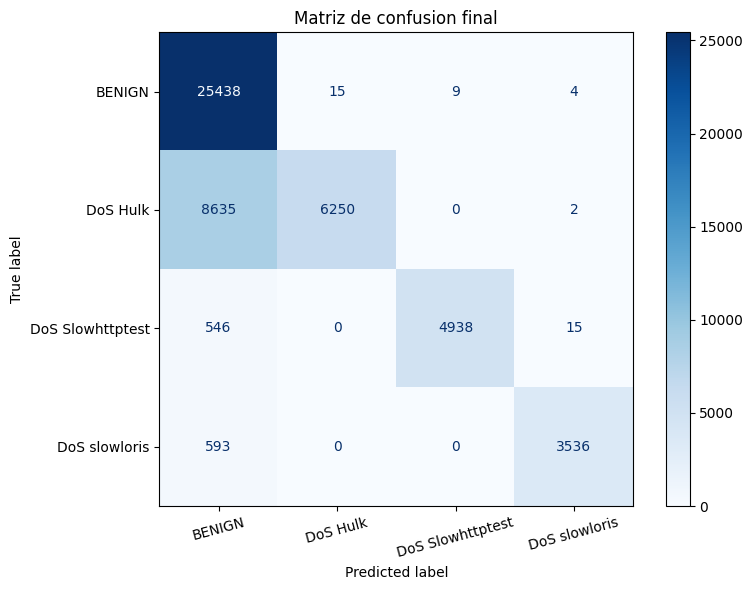

In [ ]:
clases = ['BENIGN', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris']

cm_final = confusion_matrix(y_windows, y_final_pred, labels=clases)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=clases)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de confusion final')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()